# Reinforcement Learning assignment

For the full instructions, please see the assignment pdf file!

Please remove any **instructions in italic** from this file before submitting.

# Abstract

**The Blackjack Project**


The main.ipynb file contains the framework and written report for The Blackjack Project. 

It initializes the [Blackjack-v1] environment, imports the implemented RL algorithms from dp.py, mc.py, and td.py, and executes training experiments. 

The notebook generates plots of learning curves, value functions, and policies to support algorithm comparison. It also computes evaluation metrics such as cumulative rewards and RMSE against Dynamic Programming benchmarks. Finally, it includes structured analysis and discussion of results in accordance with the project requirements.

Reinforcement Learning 2026, WG40

# 0. Environment

The choice of Blackjack-v1 environment from Gymansium was concluded based on the fact of being a classic, stochastic game with a discrete and manageable state space that perfectly suits the implementation of methods like Dynamic Programming, Monte Carlo, and Temporal Difference algorithms. Its episodic nature with clear terminal states allows for straightforward evaluation of policies. Additionally, as a predefined environment, it reduces setup time, letting us focus on algorithm implementation and comparison.

1. First we install the pygame for visual representation 

In [ ]:
%pip install pygame

2. Importing required libraries/files

In [7]:
import gymnasium as gym
import numpy as np
import importlib

import dp
import mc
import td
importlib.reload(dp)
importlib.reload(mc)
importlib.reload(td)
from dp import *
from mc import *
from td import *
# Add more imports if needed. Add these into the requirements.txt file.
import plots
from plots import *

3. Create the Blackjack-v1 environment

In [8]:
# Create amd initialise the Blackjack environment
env = gym.make('Blackjack-v1') #, render_mode="human") #for visualisation

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)
for _ in range(10000): #range being the number of rounds (temp of 10 for test)
    # this is where we insert our policies
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

env.close()

# 1. Introduction

_insert your introduction in this cell_

_describe your environment and the problem the agent has to solve_

_describe the objective of the report (e.g. comparing various RL algorithms) and how you are going to accomplish this (research question)_

_don't forget to add plots/images of the environment, can be done via code cells, but also by inserting .png files into the jupyter notebook_

# 2. Dynamic Programming algorithms

First run the Dynamic Programming algorithms (Policy Iteration and Value Iteration) by calling functions from the separate `dp.py` file, and create plots. Then, fill in the cell completing your 'report' within this file.

In [ ]:
# Call Policy Iteration algorithm

In [ ]:
# Call Value Iteration algorithm

_In this cell, describe how the algorithms work, how the algorithms differ, plot results and/or policies (add more code cells!), etc._

# 3. Monte Carlo algorithms

First run the Monte Carlo algorithm (Monte Carlo Exploring Starts or Monte Carlo without Exploring Starts (with $\epsilon$-greedy strategy)) by calling functions from the separate `mc.py` file, and create plots. Then, fill in the cell completing your 'report' within this file.

In [ ]:
# Call Monte Carlo algorithm

_In this cell, describe how the algorithms work, how the algorithms differ (compared to the one you did not code), plot results and/or policies (add more code cells!), etc._

# 4. Temporal Difference algorithms

First run the Temporal Difference algorithms (SARSA and Q-learning) by calling functions from the separate `td.py` file, and create plots. Then, fill in the cell completing your 'report' within this file.

**4.1 SARSA Algorithm**

In [ ]:
# Call SARSA algorithm

***

**4.2 Q-learning Algorithm**

Learned Policy (S=STAND, H=HIT)

Without Usable Ace:
  Sum 12: SHHSHHHHHHH
  Sum 13: SHHHSSSHHSH
  Sum 14: SHSSHHSHSHS
  Sum 15: SSHHHHSHHSS
  Sum 16: SHSSHSHHSHS
  Sum 17: SSSSSSSSSSS
  Sum 18: SSSSSSSSSHS
  Sum 19: SSSSSSSSSSS
  Sum 20: SSSSSSSSSSS
  Sum 21: SSSSSSSSSSS

With Usable Ace:
  Sum 12: SHHHHHHHHSH
  Sum 13: SHHHHHSHHHH
  Sum 14: SHHHHHHSHHH
  Sum 15: SHHHHHHHHHH
  Sum 16: SHHHSSSHHHS
  Sum 17: SHSSHHHHHHH
  Sum 18: SSSHHHSHHHH
  Sum 19: SSSSHSSSSSS
  Sum 20: SSSHSSSSSSS
  Sum 21: SSSSSSSSSSS

Average Reward: -0.093
Success Rate: 0.41

--- TRAINING EFFICIENCY PLOTS (Convergence) ---


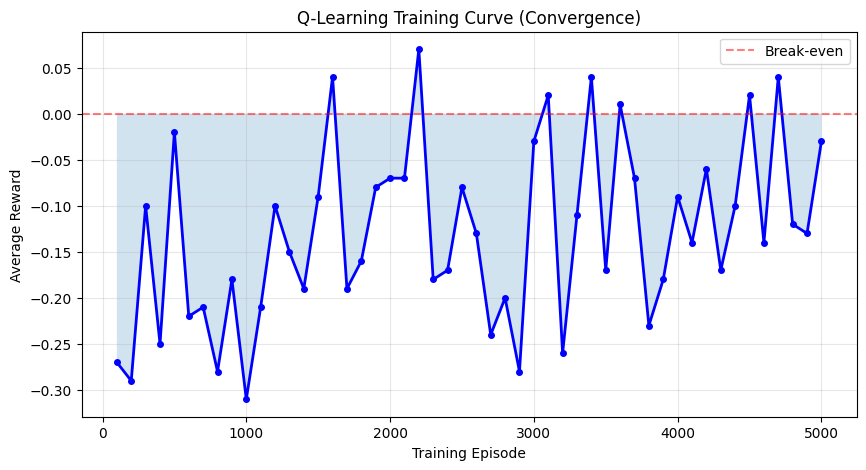

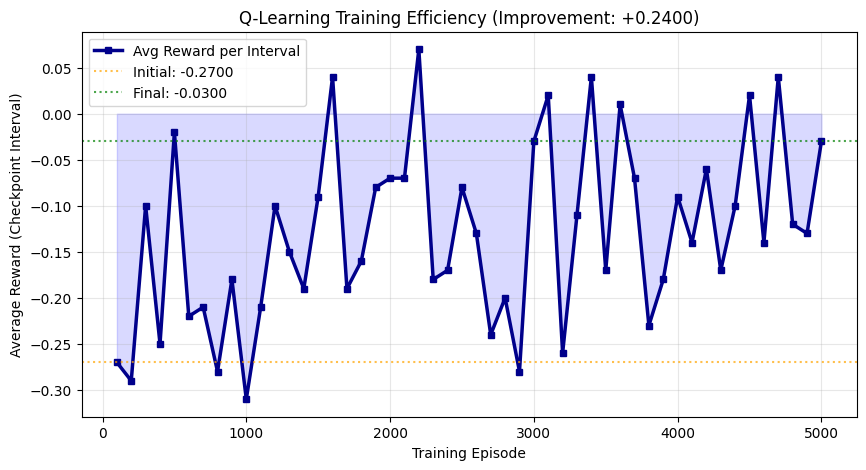

Q-Learning Training Efficiency Summary:
  Initial reward (checkpoint 1): -0.2700
  Final reward (checkpoint 50): -0.0300
  Total improvement: +0.2400
  Improvement rate: 0.48% per checkpoint

--- TEST PERFORMANCE PLOTS (Final Policy) ---


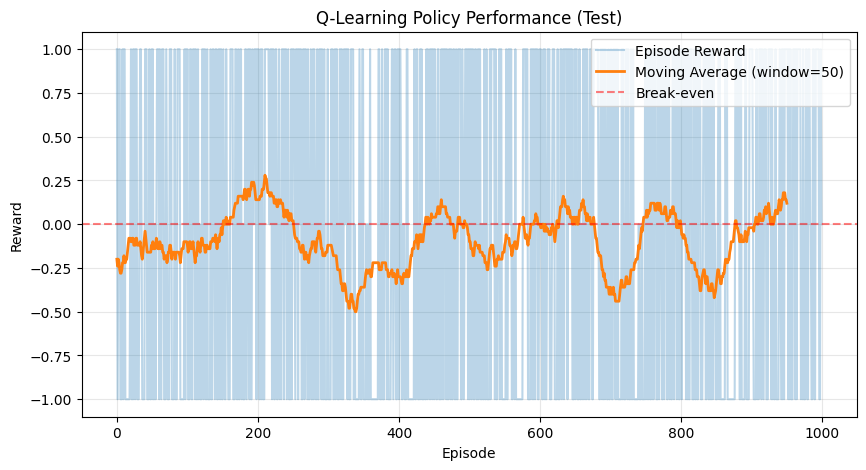

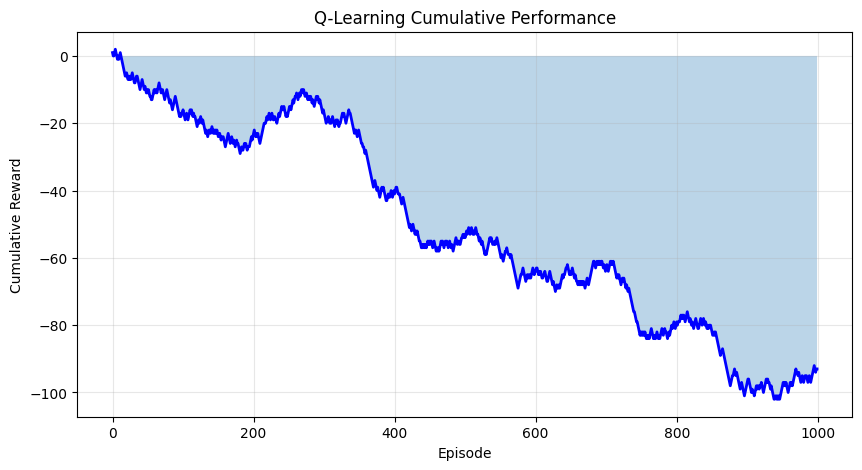

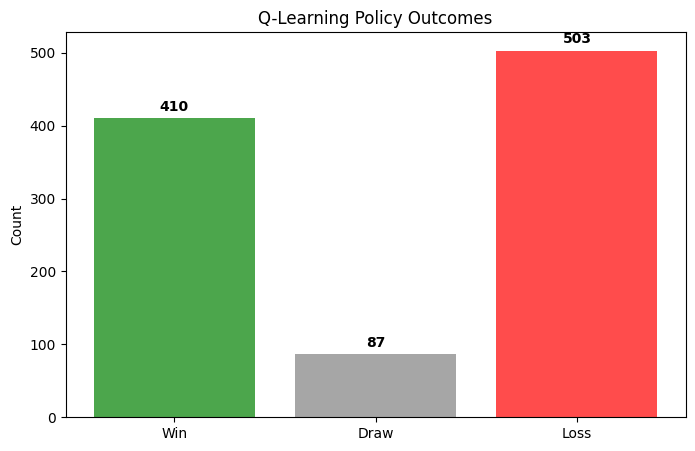

In [10]:
# Call Q-learning algorithm

#Train with tracking enabled for efficiency analysis
# num_checkpoints=100 means checkpoint every 50 episodes (5000/100) for detailed convergence tracking
Q_Learning, training_rewards, training_episodes = q_learning(env, 5000, track_training=True)
policy = np.argmax(Q_Learning, axis=-1)

policy_3d = policy.reshape(32, 11, 2)

print("Learned Policy (S=STAND, H=HIT)\n")
print("Without Usable Ace:")
for player_sum in range(12, 22):
    actions = policy_3d[player_sum, :, 0]
    action_str = ''.join(['S' if a == 0 else 'H' for a in actions])
    print(f"  Sum {player_sum}: {action_str}")

print("\nWith Usable Ace:")
for player_sum in range(12, 22):
    actions = policy_3d[player_sum, :, 1]
    action_str = ''.join(['S' if a == 0 else 'H' for a in actions])
    print(f"  Sum {player_sum}: {action_str}")

# Test
avg_reward, success_rate, rewards = test_q_learning(env, Q_Learning)

print("\nAverage Reward:", avg_reward)
print("Success Rate:", success_rate)

# Training Efficiency Visualizations
print("\n--- TRAINING EFFICIENCY PLOTS (Convergence) ---")
plot_training_curve(training_episodes, training_rewards)
plot_training_efficiency_summary(training_episodes, training_rewards)

# Test Performance Visualizations
print("\n--- TEST PERFORMANCE PLOTS (Final Policy) ---")
plot_test_results(rewards)  # Moving average + individual rewards
plot_cumulative_rewards(rewards)  # Cumulative total
plot_outcome_distribution(rewards)  # Win/Draw/Loss summary


**4.2.2 Description and Observation**

Q-Learning is an off-policy Temporal Difference (TD) control algorithm that aims to learn the optimal action-value function independently of the agent’s behavior policy. Unlike on-policy methods such as SARSA implemented in the above section of *4.1*, Q-Learning updates its estimates using the maximum possible future reward, rather than the action actually taken.

The update rule is defined as:

$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a} Q(s', a) - Q(s,a) \right]$

where:

- $α$ is the learning rate, controlling the impact of new information
- $γ$ is the discount factor, determining the importance of future rewards
- $r$ is the immediate reward
- $max_{a}​Q(s',a)$ represents the optimal future value

We handled exploration using an $ε$-greedy policy, where the agent selects a random action with probability ε and the greedy action otherwise. This balances exploration and exploitation during training.

Q-Learning separates the behavior policy (exploration) from the target policy (greedy), which allows it to converge toward an optimal policy under appropriate conditions.

**4.2.3 Implementation**

The Q-Learning algorithm was implemented using a tabular approach, where the Q-values are stored in a matrix of size $(32 * 11 * 2)$ = $704*2$, corresponding to all possible state-action pairs in the Blackjack environment.

The environment state, represented as a tuple $(𝑝𝑙𝑎y𝑒𝑟\_𝑠𝑢𝑚,𝑑𝑒a𝑙𝑒𝑟\_𝑐𝑎𝑟𝑑,𝑢𝑠𝑎𝑏𝑙𝑒\_𝑎𝑐𝑒)$, is converted into a single integer index using a custom encoding function ensuring efficient indexing into the Q-table.

Action selection is performed using an ε-greedy strategy: with probability ε, a random action is selected, and otherwise, the action with the highest Q-value is chosen.

During training, the agent interacts with the environment over multiple episodes. At each step the Q-value is updated using the Q-Learning update rule. If the episode terminates, only the immediate reward is used.
Otherwise, bootstrapping is applied using the maximum Q-value of the next state.

Additionally, training performance is tracked by periodically averaging episode rewards, enabling analysis of learning progress. Plots in plots.py capture these periods.

**4.2.4 Setup**

The algorithm was trained over multiple episodes using the following hyperparameters:

- Learning rate $α=0.1$
- Discount factor $γ=0.99$
- Exploration rate $ϵ=0.1$

Training was conducted over a sufficiently large number of episodes to ensure convergence. Performance during training was monitored using averaged reward checkpoints.

For evaluation, a separate testing phase was used, where the learned policy was executed greedily $(ε = 0)$. This ensures that performance reflects the learned policy rather than exploratory behavior.

*Note: With separating training and evaluation we ensured the measurement and observation of unbiased performance.*

**4.2.5 Result**

The performance of the trained Q-Learning agent was evaluated using the following metrics.

- Average reward       $-$      *measures overall profitability of the learned policy*
- Win rate             $-$      *proportion of episodes with positive reward*
- Reward trends        $-$      *analyzed using moving averages and cumulative reward plots*

The results indicate that the agent improves its performance over time, as evidenced by increasing cumulative rewards and stabilization of the reward signal. The moving average of rewards demonstrates convergence toward a consistent policy.

The outcome distribution (wins, losses, draws) provides additional insight into policy behavior, showing the agent’s ability to avoid unfavorable states and exploit advantageous situations.

Q-Learning demonstrates stable learning behavior and converges to a policy that outperforms random action selection.

# 5. Comparison and discussion

Compare different algorithms (MC and TD with plots). You don’t need to plot DP alongside MC and TD since DP is not a learning algorithm. However, DP can provide the ground truth for optimal state or action values, which can serve as a reference when evaluating MC and TD. You can choose to plot any of the following: cumulative reward, root mean squared error, sample efficiency, or any other metric you think is a fair comparison.

Include a discussion: what can you conclude by comparing different RL algorithms? Do they have certain strengths or limitations?

_Add as many text cells as you like_

In [ ]:
# Add as many code cells as you like

# 6. Conclusion

Conclude your project.

_Add as many text cells as you like_